# OOH Data Engineer Challenge Report
## Moises Flores Ortiz

## Introduction

This report studies the OOH billups Data Engineering Challenge. I decided to cover this report in two main sections first the Pipeline Architecure and the Business Questions as well as a potential improvements section. It is intended to show my thinking, knowledge and experience of over 5 years working as Data Engineer and developing my professional career in the software world. The technologies that I have used to build the pipeline (AWS and python) are the technologies where I have more experience however I also have experience in technologies such as Snowflake, ML/AI and Databricks.

# Pipeline Architecture

## 1) Architecture Decision

The implementation uses a hybrid architecture.

- Terraform defines a development and production platform on AWS (S3, IAM, EMR Serverless, Glue, Athena, optional MWAA).
- To avoid costs for this challenge the orchestration is run locally with Dockerized Airflow.
- PySpark jobs run in EMR Serverless and publish Bronze, Silver, and Gold outputs.
- Github actions included thinking on CI/CD potential workflows.

Why this decision:

- Shows my experience working with medallion arquitecture in AWS using PySpark.
- Demonstrates real platform design skills for scalability and maintenance.
- Keeps cloud cost controlled for job interview process.
- Preserves clear separation between infrastructure and analytics logic (Business Questions)

## 2) Data Flow in the Medallion arquitecture.

**Bronze:**

- missing merchant name is replaced with `merchant_id`
- null category is replaced with `"Unknown category"`
- no record dropped
- Normalization
- Join merchants by `merchant_id`

**Silver:**

- Adds `year_month` (for monthly aggregations) 
- `hour` in `HH00` format (for hour-based analysis)
- `is_installment` flag (`installments > 1`)


**Gold:**

- Builds one output per question and writes each to gold. This represents 1 report per business question which will be covered in the next section.

For more information about the pipeline setup, please refer to the `README.md` file in this repository.


# Business Questions

In [ ]:
# Import libraries
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import DataFrame, Window
import matplotlib.pyplot as plt

In [2]:
def get_spark(app_name: str) -> SparkSession:
    return (
        SparkSession.builder.appName(app_name)
        .config("spark.sql.session.timeZone", "UTC")
        .config("spark.sql.adaptive.enabled", "true")
        .getOrCreate()
    )

# Uitls
def normalize_transactions(df: DataFrame) -> DataFrame:
    return (
        df.withColumn("purchase_date", F.to_timestamp("purchase_date"))
        .withColumn("purchase_amount", F.col("purchase_amount").cast("double"))
        # Perform a null check and replace with 0 if null
        .withColumn("installments", F.coalesce(F.col("installments").cast("int"), F.lit(0)))
        # Perform a null check and replace with "Unknown category" if null
        .withColumn("category", F.coalesce(F.col("category"), F.lit("Unknown category")))
    )


def month_col(df: DataFrame) -> DataFrame:
    return df.withColumn("year_month", F.date_format("purchase_date", "yyyy-MM"))

In [3]:
# Read data
spark = get_spark("OOH_Pipeline")
historical_transactions = spark.read.parquet("../part-00000-tid-860771939793626614-979f966a-6d53-4896-9692-f81194d27b99-109986-1-c000.snappy.parquet")
merchants = spark.read.csv("../merchants-subset.csv", header=True, inferSchema=True)

# Normalize data
historical_transactions = normalize_transactions(historical_transactions)
# Taking merchant_id for fallback
merchants = merchants.select("merchant_id", F.col("merchant_name").alias("merchant_name_ref"))
# All data - Left join to enrich transactions
data = historical_transactions.join(merchants, on='merchant_id', how="left")
data = data.withColumn("merchant_name", F.coalesce("merchant_name_ref", F.col("merchant_id").cast("string")))
data = data.drop("merchant_name_ref")

# Add month column for upcoming aggregation
data = month_col(data)

data.show(10)

+---------------+---------------+---------------+-------+------------+--------+--------------------+---------+-------------------+--------+------------+---------------+--------------------+----------+
|    merchant_id|authorized_flag|    customer_id|city_id|installments|category|merchant_category_id|month_lag|      purchase_date|state_id|subsector_id|purchase_amount|       merchant_name|year_month|
+---------------+---------------+---------------+-------+------------+--------+--------------------+---------+-------------------+--------+------------+---------------+--------------------+----------+
|M_ID_fe83cec110|              N|C_ID_2730b57487|     63|           3|       C|                 456|       -9|2017-05-19 16:01:59|       9|          21|       18970.06| Robert Chadwick inc|   2017-05|
|M_ID_9f11c207c1|              Y|C_ID_95429da153|     38|           3|       C|                 884|       -2|2017-12-07 22:33:34|       7|          27|       14904.52| Dorothy Moore 4 inc|   2017

**Question 1:** Generate the top 5 merchants by purchase_amount for each month in the dataset,
for each city in the dataset.

In [4]:
def top_5_merchants_by_month_city(data: DataFrame) -> DataFrame:
    agg = data.groupBy(['merchant_name','year_month', 'city_id']).agg(
        F.round(F.sum('purchase_amount'), 2).alias('purchase_total')
        )
    w = Window.partitionBy(['year_month', 'city_id']).orderBy(F.desc('purchase_total'))
    return agg.withColumn('rank', F.row_number().over(w)).filter(F.col('rank') <= 5)

q1 = top_5_merchants_by_month_city(data)
q1.show()

+--------------------+----------+-------+--------------+----+
|       merchant_name|year_month|city_id|purchase_total|rank|
+--------------------+----------+-------+--------------+----+
|Rhonda Cunningham...|   2017-01|      3|     719652.68|   1|
| Dennis Mcmillan inc|   2017-01|      3|     438990.09|   2|
|Solomon Deshayes inc|   2017-01|      3|     291376.28|   3|
| Donnie Sefcovic inc|   2017-01|      3|     275845.32|   4|
|     Lisa Stulce inc|   2017-01|      3|     265200.03|   5|
|Sheila Bissonnett...|   2017-01|      7|     291940.64|   1|
|        Don Lenz inc|   2017-01|      7|     290927.05|   2|
|    Kathy Briggs inc|   2017-01|      7|     220037.87|   3|
|   Mable Galarza inc|   2017-01|      7|      209030.1|   4|
|     Rose Hart 2 inc|   2017-01|      7|     189396.03|   5|
|     Mike Sparks inc|   2017-01|      8|     971431.74|   1|
| Larry Stegall 2 inc|   2017-01|      8|     816934.14|   2|
| Carlotta Schell inc|   2017-01|      8|     593485.13|   3|
|  Sandr

Findings:

This view helps the business identify the top-performing merchants by city and monitor how merchant performance changes month over month. For example, in city_id = 3 during 2017-01, Rhonda Cunningham has the highest purchase total. From that baseline, the team can track whether the same merchant remains a leader in subsequent months, or whether rankings shift over time.

**Question 2:** What is the average sale amount (purchase_amount) of each merchant in each
state. Consider returning the merchants with the largest sales first:

In [5]:
def avg_sale_amount_by_merchant_state(data: DataFrame) -> DataFrame:
    agg = data.groupBy(['merchant_name','state_id']).agg(
        F.round(F.avg('purchase_amount'), 2).alias('avg_purchase_amount')
        )
    return agg.orderBy(F.desc('avg_purchase_amount'))

q2 = avg_sale_amount_by_merchant_state(data)
q2.show()

+--------------------+--------+-------------------+
|       merchant_name|state_id|avg_purchase_amount|
+--------------------+--------+-------------------+
|  Martha Tyrrell inc|       7|           39937.61|
|  Julie Mckelvey inc|       9|           39727.59|
|   Jennifer Pool inc|      24|           39658.71|
|    Ileana Owens inc|       9|           39649.56|
|  Robert Mullins inc|      15|           39642.69|
|Christopher Hamil...|      20|           39602.72|
|      Raul Creed inc|       2|           39569.62|
|    Samuel Evans inc|      15|            39558.6|
|   Pamela Ulrich inc|      13|           39556.68|
|  Dawn Ellington inc|      16|           39556.68|
| Mario Marroquin inc|       5|           39550.66|
|   Martha Meaney inc|      -1|           39541.64|
| Gertrude Leslie inc|       5|            39541.6|
|   Dorothy Zemel inc|      16|           39532.16|
|William Harris 2 inc|       4|            39531.7|
| Thomas Wright 3 inc|       7|           39502.42|
|     Anna G

Findings:

This analysis shows merchant performance by state, helping the business identify where each merchant performs best. It highlights the states with the strongest average transaction value for each merchant. In this result, for example, Martha Tyrrell Inc has the highest average purchase amount in state 7.

**Question 3:** Identify the top 3 hours where the largest amount of sales (purchase_amount) are
recorded for each product category (category).

In [6]:
from pyspark.sql.types import DecimalType

def top_3_hours_by_category(data: DataFrame) -> DataFrame:
    data = data.withColumn('hour', F.date_format('purchase_date', 'HH00'))
    agg = data.groupBy(['category','hour']).agg(
        F.round(F.sum('purchase_amount'), 2).cast(DecimalType(20,2)).alias('total_sales')
        )
    w = Window.partitionBy('category').orderBy(F.desc('total_sales'))
    return agg.withColumn('rank', F.row_number().over(w)).filter(F.col('rank') <= 3)

q3 = top_3_hours_by_category(data)
q3.show()

+----------------+----+-------------+----+
|        category|hour|  total_sales|rank|
+----------------+----+-------------+----+
|               A|1200|5994716472.60|   1|
|               A|1300|5903766112.97|   2|
|               A|1700|5716664629.44|   3|
|               B|1300|4461261344.75|   1|
|               B|1200|4304796955.98|   2|
|               B|1400|4238870560.78|   3|
|               C|1700| 854094298.82|   1|
|               C|1600| 847907281.24|   2|
|               C|1500| 826589405.04|   3|
|Unknown category|0000| 230079357.99|   1|
|Unknown category|1400|  65209588.22|   2|
|Unknown category|1300|  64572632.14|   3|
+----------------+----+-------------+----+



Findings:

Using historical transactions, this analysis identifies the most important sales hours for each product category. It helps the business plan inventory and operations, for example by ensuring high demand products are available during peak hours. In this result, the top sales hour for category A is 12:00 PM. The view also shows transactions under Unknown category. From a data engineering perspective, this should trigger a follow-up investigation to understand why categories are missing and reduce these cases over time, improving data quality for business decisions.

**Question 4:** In which cities are the most popular merchants located. Is there a correlation
between the location (city_id) and the categories (category) the merchant sells.
Note: Consider popularity in terms of the number of sales transactions of each merchant.

In [7]:
def popular_merchants_city_category(data: DataFrame) -> DataFrame:
    merchant_city = (
        data.groupBy("merchant_name", "city_id", "category")
        .agg(F.count(F.lit(1)).alias("tx_count"))
        .orderBy(F.desc("tx_count"))
    )

    # share of each category within city transaction volume.
    city_total = data.groupBy("city_id").agg(F.count(F.lit(1)).alias("city_tx_total"))
    category_city = data.groupBy("city_id", "category").agg(F.count(F.lit(1)).alias("category_tx_count"))

    city_category_share = (
        category_city.join(city_total, "city_id")
        .withColumn("category_share", F.col("category_tx_count") / F.col("city_tx_total"))
    )

    return merchant_city.join(city_category_share, ["city_id", "category"], "left").orderBy(
        F.desc("tx_count"), F.asc("city_id") ,F.desc("category_share"))

q4 = popular_merchants_city_category(data)
q4.show(40)


+-------+--------+--------------------+--------+-----------------+-------------+-------------------+
|city_id|category|       merchant_name|tx_count|category_tx_count|city_tx_total|     category_share|
+-------+--------+--------------------+--------+-----------------+-------------+-------------------+
|     69|       A|   John Miller 7 inc|  165899|           818726|      1480126| 0.5531461510709224|
|     69|       A|   Nilda Richter inc|  165899|           818726|      1480126| 0.5531461510709224|
|      1|       B|  Kathie Sughrue inc|  106731|           459343|       667093| 0.6885741568267093|
|     69|       B|   John Miller 7 inc|   85842|           582642|      1480126| 0.3936435141332562|
|     69|       B|   Nilda Richter inc|   85842|           582642|      1480126| 0.3936435141332562|
|      1|       B|      Cesar Hall inc|   44787|           459343|       667093| 0.6885741568267093|
|      1|       B|     Mary Gray 7 inc|   44063|           459343|       667093| 0.68857415

Findings:

This view shows that the most popular merchants, measured by transaction count, are concentrated in cities 69 and 1. It also adds category share at the city level, which helps assess the relationship between location and what merchants sell. For example, in city 69, category A represents about 55% of all transactions, indicating strong category concentration. In city 1, category B represents about 69% of transactions, showing an even stronger concentration pattern. This suggests a meaningful link between city and category demand.

**Question 5:** A new merchant is coming in to do business and you have been assigned to give
advice based strictly on the historical transactions. You are expected to provide a response to
the following questions.

In [8]:
# Read data
spark = get_spark("OOH_Pipeline")
def recomendations_base(data: DataFrame) -> DataFrame:
    data = data.withColumn('hour', F.date_format('purchase_date', 'HH00'))
    agg = data.groupBy(['city_id', 'category', 'year_month', 'hour']).agg(
        F.sum("purchase_amount").cast(DecimalType(20,2)).alias("sales_amount"),
        F.count(F.lit(1)).alias("sales_count"),
        F.round(F.avg("installments"), 2).alias("avg_installments"),
        )
    return agg

q5 = recomendations_base(data)
q5.show()

+-------+--------+----------+----+------------+-----------+----------------+
|city_id|category|year_month|hour|sales_amount|sales_count|avg_installments|
+-------+--------+----------+----+------------+-----------+----------------+
|    188|       B|   2017-02|1200|   375293.77|         18|             1.0|
|     19|       A|   2017-06|1100| 17111678.56|        854|             0.0|
|     57|       A|   2017-08|2000|  3200722.95|        160|             0.0|
|    158|       B|   2017-09|2300| 11389751.55|        565|             1.0|
|      4|       B|   2018-01|1900|  1656714.51|         92|             1.0|
|      1|       B|   2018-02|0800| 48917154.60|       2453|             1.0|
|     69|       C|   2018-02|2200|  1093910.95|         56|            3.29|
|    179|       B|   2017-11|0000|  4459788.65|        207|             1.0|
|     12|       A|   2017-06|2100|   760099.42|         38|             0.0|
|    137|       A|   2017-04|1700|  7161714.72|        350|             0.0|

In [9]:
# Complement of Q-A
q5.groupBy("city_id").agg(F.sum("sales_amount").alias("total_sales")).orderBy(
    F.desc("total_sales")).show(5)

+-------+--------------+
|city_id|   total_sales|
+-------+--------------+
|     69|29735961281.34|
|      1|13412575016.96|
|     19| 5797239502.75|
|    158| 5617963725.58|
|     17| 5053468063.97|
+-------+--------------+
only showing top 5 rows



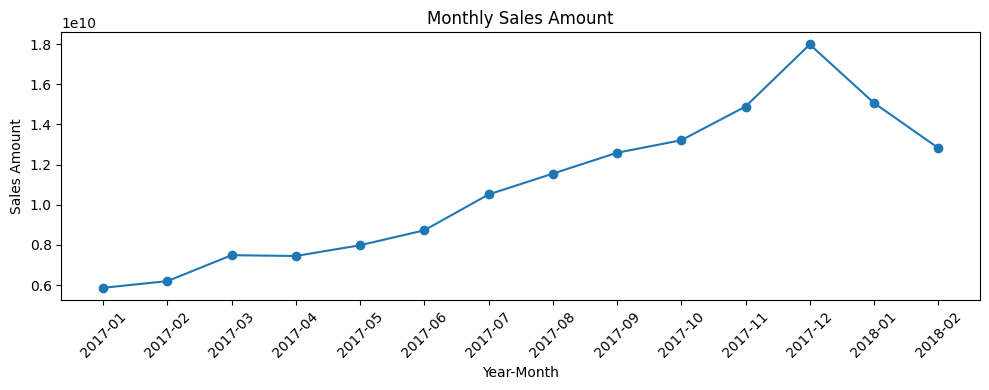

In [ ]:
# Complement of Q-C

q5_c = (
    q5.groupBy("year_month")
      .agg(F.sum("sales_amount").alias("sales_amount"))
      .orderBy("year_month")
)

pdf = q5_c.toPandas()

plt.figure(figsize=(10, 4))
plt.plot(pdf["year_month"], pdf["sales_amount"], marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Sales Amount")
plt.xlabel("Year-Month")
plt.ylabel("Sales Amount")
plt.tight_layout()
plt.show()

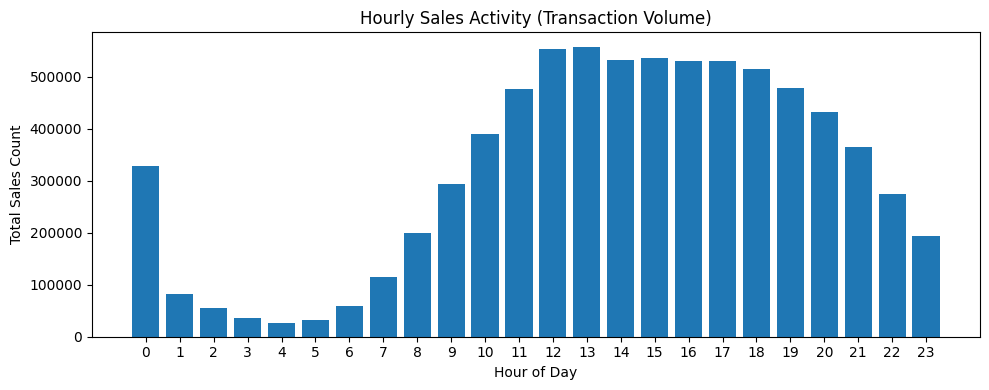

In [12]:
# Complement of Q-D
hourly = (
    q5.groupBy("hour")
      .agg(
          F.sum("sales_count").alias("total_sales_count"),
          F.sum("sales_amount").alias("total_sales_amount")
      )
      .withColumn("hour_int", F.regexp_replace(F.col("hour"), "00$", "").cast("int"))
      .orderBy("hour_int")
)

pdf = hourly.select("hour_int", "total_sales_count", "total_sales_amount").toPandas()

plt.figure(figsize=(10, 4))
plt.bar(pdf["hour_int"], pdf["total_sales_count"], width=0.8)
plt.xticks(range(24))
plt.xlabel("Hour of Day")
plt.ylabel("Total Sales Count")
plt.title("Hourly Sales Activity (Transaction Volume)")
plt.tight_layout()
plt.show()

Findings:

a.Which cities would you advise them to focus on and why?

I would recommend prioritizing the top five cities by total sales, since historical data shows these markets are consistently the most active and offer the strongest revenue potential. However, this is a high-level view, and the next step should be a deeper analysis to understand what is driving performance in each city, such as merchant density and/or category mix.

b. Which categories would you recommend they sell

For category selection, I would use the results from Question 4, where we analyzed category share and its relationship with sales concentration by city. Based on that evidence, I would prioritize category A in cities 69 and 158, and category B in city 1, since those city category combinations show stronger demand patterns in the historical data.

c. Are there particular periods (months) that have interesting sales behaviors?

The monthly trend shows stronger sales in the second half of the year, with December as the peak month. This suggests a clear seasonal pattern, so the business should plan inventory and promotions more aggressively during that period.


d. What hours would you recommend they open and close for the day?

Based on the histogram, sales transactions are concentrated between 10:00 AM and 9:00 PM. A practical first recommendation is to operate within that time window, since it captures the highest demand periods and avoids low activity hours.


## Improvements

### Incremental Processing Approach

Current execution is full refresh.  
A production improvement would move to incremental processing:

- track processed time windows or file checkpoints
- process only new or changed records
- apply upsert/merge strategy in curated layers
- keep idempotent reruns for failed windows


### Schema Evolution Approach

Current scope assumes stable schema.  
For production, schema evolution should be handled explicitly:

- enforce schema contracts at ingestion
- maintain versioned table definitions in Glue/Athena
- alert on incompatible type changes


### Pipeline Assumptions and Limitations

- Recommendations are based only on provided historical data
- No external factors (campaigns, macro events, weather) were included
- Quality checks are focused on challenge requirements, not a full governance framework

## Evidence of Pipeline Execution

## Dag (AWS Services Architecture)
![dag](images/DAG_Exec.PNG)

## Buckets for Medallion Architecture
![s3](images/S3_buckets.PNG)